# Get code lists

In [79]:
import pandas as pd

df = pd.read_parquet("../data/validation.parquet")

human_codes = df[df["label"] == 0]["code"].tolist()
ai_codes = df[df["label"] == 1]["code"].tolist()

print(len(human_codes), len(ai_codes))

47695 52305


In [80]:
df = pd.read_parquet("../data/test_sample.parquet")

test_human_codes = df[df["label"] == 0]["code"].tolist()
test_ai_codes = df[df["label"] == 1]["code"].tolist()

print(len(test_human_codes), len(test_ai_codes))

777 223


# Mean & std of features

In [96]:
import re
import numpy as np

def extract_top_features(code):
    if not code or not code.strip():
        return {
            "blank_line": 0.0,
            "whitespace": 0.0,
            "comment": 0.0,
            "pr_lines": 0.0,
            "line_length": 0.0,
            "space_tab_ratio": 0.0
        }

    # Feat 1: blank lines ratio
    lines = code.strip().split('\n')
    total_lines = len(lines)
    
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / total_lines if total_lines > 0 else 0.0

    # Feat 2: whitespace ratio
    whitespaces = [l.count(' ') + 4 * l.count('\t') for l in lines]
    mean_whitespaces = np.mean(whitespaces)
    whitespace_ratio = np.std(whitespaces) / mean_whitespaces if mean_whitespaces > 0 else 0.0

    # Feat 3: comment ratio
    # Find '//' and '#'
    comment_lines = sum(1 for line in lines if re.search(r'(?://|#)', line))
    comment_ratio = comment_lines / total_lines if total_lines > 0 else 0.0

    # Feat 4: paragraph
    pr_lines = [pr.count('\n') for pr in code.split("\n\n") if len(pr) > 0]
    std_pr_lines = np.std(pr_lines) 
    pr_lines_ratio = std_pr_lines / (np.mean(pr_lines) + std_pr_lines) if std_pr_lines > 0 else 0.0

    # Feat 5: Line length 
    line_lens = [len(l) for l in lines]
    line_length = np.std(line_lens)/np.mean(line_lens) if len(line_lens) > 0 else 0.0

    # Feat 6: Space-tab ratio
    spaces = code.count(' ')
    tabs = 4 * code.count('\t')
    space_tab_ratio = spaces/(spaces + tabs) if spaces > 0 else 0.0



    return {
        "blank_line": round(blank_line_ratio, 4),
        "whitespace": round(whitespace_ratio, 4),
        "comment": round(comment_ratio, 4),
        "pr_lines": round(pr_lines_ratio, 4),
        "line_length": round(line_length, 4),
        "space_tab_ratio": round(space_tab_ratio, 4)
    }

def features_statistics(codes, return_lists=False):
    feats_dict = {}

    for code in codes:
        feats = extract_top_features(code)
        for k, v in feats.items():
            feats_dict.setdefault(k, []).append(v)

    if return_lists:
        return list(feats_dict.values())

    statistics = {
        k: [round(np.mean(v), 3), round(np.std(v), 3)]
        for k, v in feats_dict.items()
    }

    return statistics

# Diagrams

In [97]:
human_feat_lists = features_statistics(human_codes[10000:12000], return_lists=True)
ai_feat_lists = features_statistics(ai_codes[10000:12000], return_lists=True)

test_human_feat_lists = features_statistics(test_human_codes, return_lists=True)
test_ai_feat_lists = features_statistics(test_ai_codes, return_lists=True)

### 1D Diagram (1 feature)

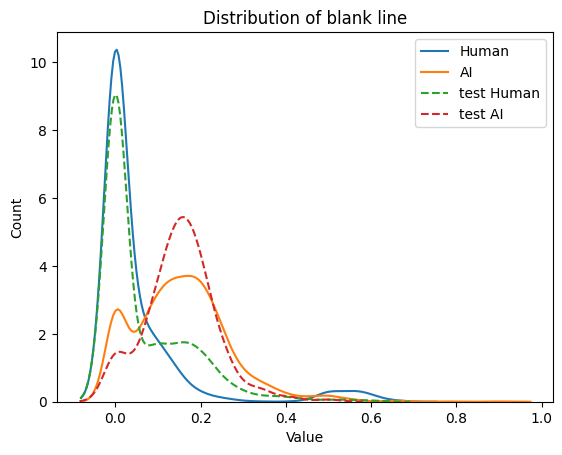

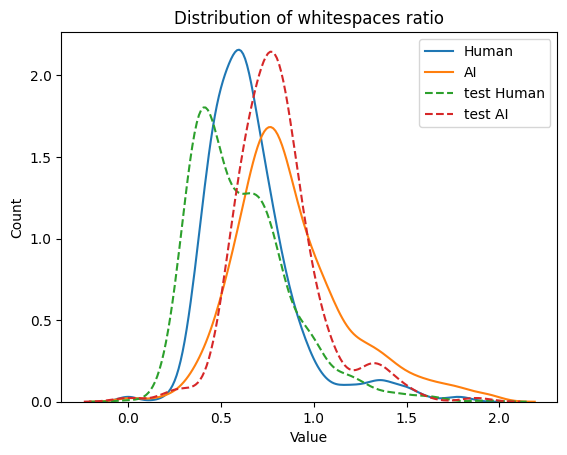

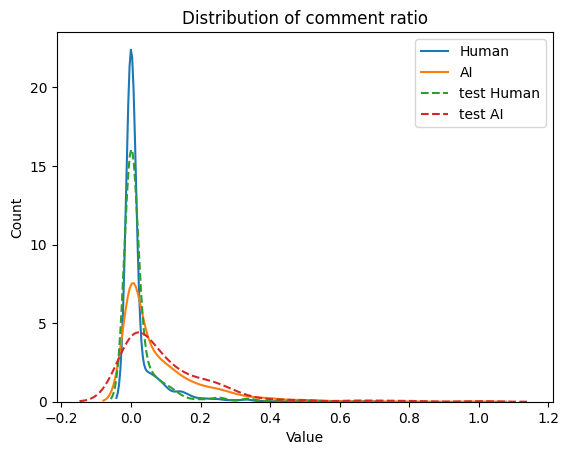

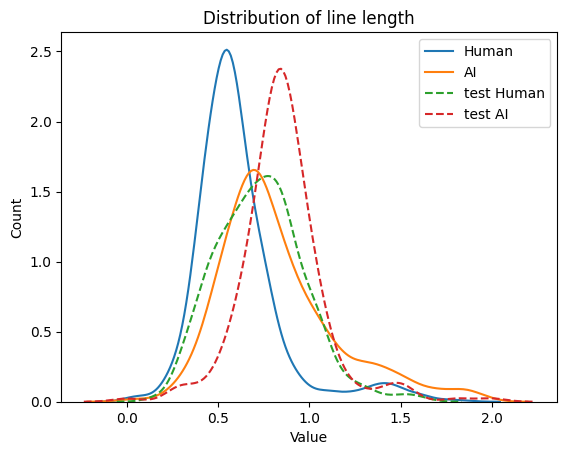

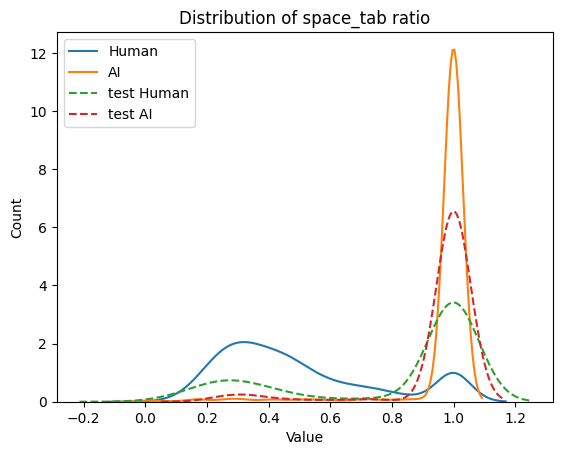

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

feat_names = ["blank line", "whitespaces ratio", "comment ratio", "Paragraph lines ratio", "line length", "space_tab ratio"]

for feat_idx in [0, 1, 2, 4, 5]:
    human = [x for x in human_feat_lists[feat_idx] if x < 2]
    ai = [x for x in ai_feat_lists[feat_idx] if x < 2]

    test_human = [x for x in test_human_feat_lists[feat_idx] if x < 2]
    test_ai = [x for x in test_ai_feat_lists[feat_idx] if x < 2]

    plt.figure()

    sns.kdeplot(human, label="Human")
    sns.kdeplot(ai, label="AI")

    sns.kdeplot(test_human, label="test Human", linestyle="--")
    sns.kdeplot(test_ai, label="test AI", linestyle="--")

    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title("Distribution of " + feat_names[feat_idx])
    plt.legend()
    plt.show()


### 2D diagram (2 features)

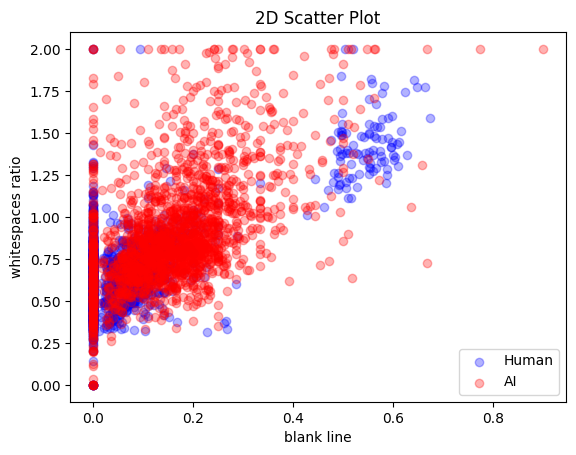

In [ ]:
idx1, idx2 = 0, 1 

# human1 = np.clip([x for x in test_human_feat_lists[idx1]], 0, 2)
# human2 = np.clip([x for x in test_human_feat_lists[idx2]], 0, 2)
# ai1 = np.clip([x for x in test_ai_feat_lists[idx1]], 0, 2)
# ai2 = np.clip([x for x in test_ai_feat_lists[idx2]], 0, 2)

human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)


import matplotlib.pyplot as plt

plt.figure()

plt.scatter(human1, human2, color='blue', alpha=0.3, label="Human")
plt.scatter(ai1, ai2, color='red', alpha=0.3, label="AI")

plt.xlabel(feat_names[idx1])
plt.ylabel(feat_names[idx2])
plt.title("2D Scatter Plot")

plt.legend()

plt.show()


### 3D diagram

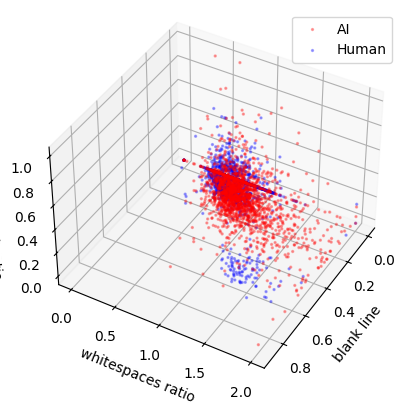

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

idx1, idx2, idx3 = 0, 1, 2

human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
human3 = np.clip([x for x in human_feat_lists[idx3]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)
ai3 = np.clip([x for x in ai_feat_lists[idx3]], 0, 2)

# human1 = np.clip([x for x in test_human_feat_lists[idx1]], 0, 2)
# human2 = np.clip([x for x in test_human_feat_lists[idx2]], 0, 2)
# human3 = np.clip([x for x in test_human_feat_lists[idx3]], 0, 2)
# ai1 = np.clip([x for x in test_ai_feat_lists[idx1]], 0, 2)
# ai2 = np.clip([x for x in test_ai_feat_lists[idx2]], 0, 2)
# ai3 = np.clip([x for x in test_ai_feat_lists[idx3]], 0, 2)

ax.scatter(ai1, ai2, ai3, color='red', alpha=0.3, s = 2, label="AI")
ax.scatter(human1, human2, human3, color='blue', alpha=0.3, s = 2, label="Human")

ax.set_xlabel(feat_names[idx1])
ax.set_ylabel(feat_names[idx2])
ax.set_zlabel(feat_names[idx3])

ax.view_init(elev=40, azim=30)
ax.legend()

plt.show()


In [ ]:
!python -m pip install nbformat>=4.2.0

In [121]:
import plotly.express as px
import pandas as pd

# Choose features
idx1, idx2, idx3 = 0, 1, 2

# human1 = np.clip([x for x in test_human_feat_lists[idx1]], 0, 2)
# human2 = np.clip([x for x in test_human_feat_lists[idx2]], 0, 2)
# human3 = np.clip([x for x in test_human_feat_lists[idx3]], 0, 2)
# ai1 = np.clip([x for x in test_ai_feat_lists[idx1]], 0, 2)
# ai2 = np.clip([x for x in test_ai_feat_lists[idx2]], 0, 2)
# ai3 = np.clip([x for x in test_ai_feat_lists[idx3]], 0, 2)

human1 = np.clip([x for x in human_feat_lists[idx1][:10000]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2][:10000]], 0, 2)
human3 = np.clip([x for x in human_feat_lists[idx3][:10000]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1][:10000]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2][:10000]], 0, 2)
ai3 = np.clip([x for x in ai_feat_lists[idx3][:10000]], 0, 2)

feat1, feat2, feat3 = feat_names[idx1], feat_names[idx2], feat_names[idx3] 

df_human = pd.DataFrame({
    feat1: human1,
    feat2: human2,
    feat3: human3,
    "label": ["Human"] * len(human1)
})

df_ai = pd.DataFrame({
    feat1: ai1,
    feat2: ai2,
    feat3: ai3,
    "label": ["AI"] * len(ai1)
})

df = pd.concat([df_human, df_ai], ignore_index=True)

fig = px.scatter_3d(df, x=feat1, y=feat2, z=feat3, color='label')
fig.update_traces(marker=dict(size=3), opacity=0.4)
fig.show()
